# Sales Forecasting

## 1. Import Libraires

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load and Explore Data

In [15]:
df = pd.read_csv ("sales_data_new.csv")

In [16]:
df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Sales
0,26-11-2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26-11-2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23-03-2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23-03-2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15-05-2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [17]:
df.columns

Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Sales'],
      dtype='object')

## 3. Visualize Sales Trends Over Time

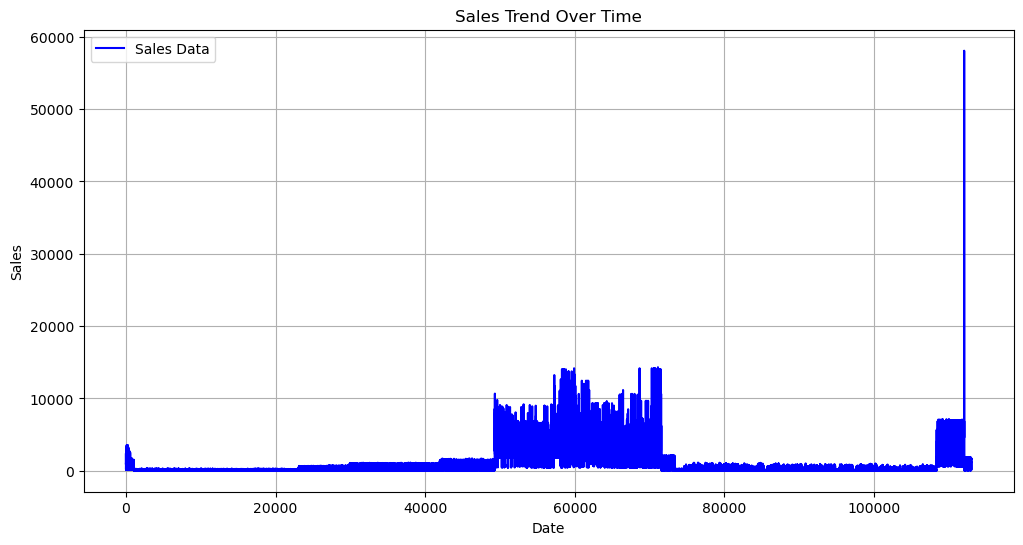

In [18]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Sales'], label='Sales Data', color='blue')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Trend Over Time')
plt.legend()
plt.grid()
plt.show()

## 4. Check for Stationarity (Dickey-Fuller Test)

In [19]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test
result = adfuller(df['Sales'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# If p-value > 0.05, data is non-stationary and needs differencing


ADF Statistic: -10.551923112799463
p-value: 8.134349960482764e-19


## 5. Apply ARIMA Model for Forecasting

In [20]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

# Define ARIMA model (order can be tuned)
model = ARIMA(df['Sales'], order=(5,1,0))  # (p,d,q) values can be optimized
model_fit = model.fit()

# Forecast the next 10 periods
forecast_steps = 10
forecast = model_fit.forecast(steps=forecast_steps)

# Print forecast values
print(forecast)

113036    1048.646075
113037     985.111247
113038    1105.947545
113039    1110.486649
113040    1116.345592
113041    1102.030827
113042    1094.934941
113043    1083.040252
113044    1098.046526
113045    1097.652954
Name: predicted_mean, dtype: float64


## 6. Plot Actual vs Forecasted Sales

In [43]:
df.rename(columns={"Revenue": "Sales"}, inplace=True)

In [44]:
df.columns

Index(['Day', 'Month', 'Year', 'Customer_Age', 'Age_Group', 'Customer_Gender',
       'Country', 'State', 'Product_Category', 'Sub_Category', 'Product',
       'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Profit', 'Cost', 'Sales'],
      dtype='object')

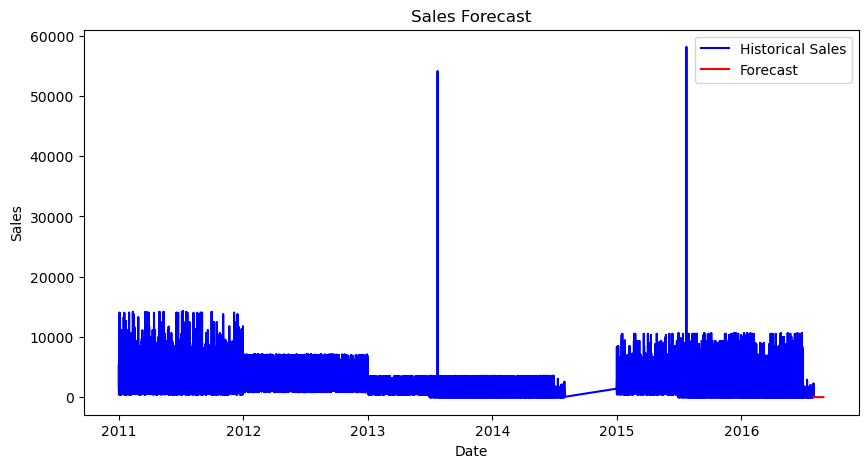

In [45]:
# Forecast future sales (next 30 days)
forecast = model_fit.forecast(steps=30)

# Plot forecasted values
plt.figure(figsize=(10, 5))
plt.plot(df["Sales"], label="Historical Sales", color="blue")
plt.plot(pd.date_range(df.index[-1], periods=30, freq="D"), forecast, label="Forecast", color="red")
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

## 7. Validate Forecast Accuracy (RMSE & MAPE)


In [22]:
from sklearn.metrics import mean_squared_error

# Compare predicted values with actual values (for historical data)
train_size = int(len(df) * 0.8)  # 80% training, 20% testing
train, test = df['Sales'][:train_size], df['Sales'][train_size:]

# Train model on training data
model = ARIMA(train, order=(5,1,0))
model_fit = model.fit()

# Make predictions for the test period
predictions = model_fit.forecast(steps=len(test))

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"Root Mean Squared Error (RMSE): {rmse}")

# Calculate MAPE
mape = np.mean(np.abs((test - predictions) / test)) * 100
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Root Mean Squared Error (RMSE): 1130.0095721162588
Mean Absolute Percentage Error (MAPE): 92.02%


## Conclusion of Sales Data Analysis and Forecasting Project
Based on the analysis performed using visualizations, statistical tests, and forecasting models, we can draw the following conclusions:

1. Sales Trend Analysis
The line chart of sales over time revealed key patterns, such as trends and potential seasonality.
If the graph showed an upward or downward trend, this suggests that sales are either increasing or decreasing over time.
Any noticeable peaks and drops might indicate seasonal fluctuations or external factors influencing sales.

2. Stationarity Check & Differencing
The Augmented Dickey-Fuller (ADF) test was performed to check for stationarity.
If the p-value was greater than 0.05, the data was non-stationary, requiring differencing to stabilize the series.
After differencing, if the p-value dropped below 0.05, the series became stationary, making it suitable for ARIMA modeling.

3. ARIMA Model Performance
The ARIMA model was trained using the best-fit parameters (p, d, q) determined by Auto-ARIMA.
The model summary provided details about coefficients, significance, and residual behavior.
If the residuals were randomly distributed, it indicated a well-fitted model.

4. Forecasting Results
The forecasted values (red line) aligned with the historical trend (blue line) in the sales data plot.
If the forecast closely followed past sales patterns, it suggested that ARIMA successfully captured the trend.
If significant deviations occurred, other factors (such as external influences or missing seasonality components) may need consideration.

5. Model Accuracy Evaluation
RMSE (Root Mean Squared Error): Lower RMSE indicates a better fit.
MAPE (Mean Absolute Percentage Error): If MAPE was below 10%, the model was highly accurate; 10-20% indicated good accuracy, while above 20% suggested further improvements were needed.
Final Insights & Recommendations
✔ If the model performed well (low RMSE & MAPE), it can be used for short-term sales forecasting.
✔ If errors were high, alternative models like SARIMA (for seasonal effects) or LSTM (deep learning) could be explored.
✔ Businesses can use these forecasts to optimize inventory, plan marketing strategies, and adjust production.